# More Line Fitting and Reading from A File with GDP Data

Lets look at some real data and fit a line.  [Life expectencay verus GDP](https://ourworldindata.org/grapher/life-expectancy-vs-gdp-per-capita?xScale=linear) is a common graph.  Let's learn about it.  We are going to

* Read it in as an excel
* Save and Read it in as a csv
* fit a line to the data
* See if we like the fit
* Then for a bonus recreate the plot from the web.


In order to do this we need to start working with Pandas.  I am rearranging a few classes so lets see how it goes.   Pandas is for Panel Data and it is really like reading in and working with excel sheets.  It is going to take us a long time to learn all about it. Unlike Midnights or Tortured Poets Departments Pandas is too big to drop in one day.  So consider this more of a start and don't worry soon you'll get better.  


YOU MIGHT need to add tge library openpyxl

uv add openpyxl 

In [1]:
import pandas as pd  # A new one today!
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(legacy='1.25') #removes the funny printing

Step 1.
* get GDP_LifeExpectancy2018.xlsx from github
* read it in.
* in pandas you name things df.  df means dataframe.  I sometimes add a second part to the name like dfGDP but other times I just name df. 
* then in the next cell just type df to look at it.  just typing df looks nicer than print(df)
* you might need to install openpyxl (I did)

In [2]:
df=pd.read_excel('GDP_LifeExpectancy2018.xlsx')

In [3]:
df

,Country,Code,Year,LifeExpectancy,GDP per capita,Population,Continent,PrintName
0,Afghanistan,AFG,2018,63.0810,1934.5550,36686788,Asia,NaN
1,Albania,ALB,2018,79.1838,11104.1660,2877019,Europe,NaN
2,Algeria,DZA,2018,76.0656,14228.0250,41927008,Africa,NaN
3,Angola,AGO,2018,62.1438,7771.4420,31273538,Africa,NaN
4,Argentina,ARG,2018,76.9994,18556.3830,44413592,South America,NaN
...,...,...,...,...,...,...,...,...
160,Venezuela,VEN,2018,71.9788,10709.9500,29825652,South America,NaN
161,Vietnam,VNM,2018,73.9757,6814.1420,94914328,Asia,NaN
162,Yemen,YEM,2018,64.5751,2284.8900,30790514,Asia,NaN
163,Zambia,ZMB,2018,62.3422,3534.0337,17835898,Africa,NaN


In [4]:
print(df)

         Country Code  Year  LifeExpectancy  GDP per capita  Population  \
0    Afghanistan  AFG  2018         63.0810       1934.5550    36686788   
1        Albania  ALB  2018         79.1838      11104.1660     2877019   
2        Algeria  DZA  2018         76.0656      14228.0250    41927008   
3         Angola  AGO  2018         62.1438       7771.4420    31273538   
4      Argentina  ARG  2018         76.9994      18556.3830    44413592   
..           ...  ...   ...             ...             ...         ...   
160    Venezuela  VEN  2018         71.9788      10709.9500    29825652   
161      Vietnam  VNM  2018         73.9757       6814.1420    94914328   
162        Yemen  YEM  2018         64.5751       2284.8900    30790514   
163       Zambia  ZMB  2018         62.3422       3534.0337    17835898   
164     Zimbabwe  ZWE  2018         61.4141       1611.4052    15052191   

         Continent  PrintName  
0             Asia        NaN  
1           Europe        NaN  
2  

The first pandas trick is df.describe().  This gives you all the basic stats.  Remember how python works that describe is a function working on your df

In [5]:
df.describe()

,Year,LifeExpectancy,GDP per capita,Population,PrintName
count,165.0,165.000000,165.000000,1.650000e+02,13.0
mean,2018.0,72.631356,19053.786587,4.598704e+07,1.0
std,0.0,7.792401,20346.341739,1.575906e+08,0.0
min,2018.0,52.553600,623.488900,7.084000e+04,1.0
25%,2018.0,66.306400,4440.382000,4.270717e+06,1.0
50%,2018.0,73.975700,12165.795000,1.063328e+07,1.0
75%,2018.0,78.662200,27370.555000,3.239927e+07,1.0
max,2018.0,85.245600,153764.170000,1.417069e+09,1.0


But today we are just going to touch the surface of pandas and learn about files and then use the data.  
First goal.  
Read Data as CSV
Comma Seperated Value
1. Save excel file as csv. 
1. open in excel.  NOT numbers
1. save as  ms-dos csv
1. open with notes or text edit.  What does it look like?
1. now open with python


In [6]:
df=pd.read_csv('GDP_LifeExpectancy2018.csv')

In [7]:
df

,Country,Code,Year,LifeExpectancy,GDP per capita,Population,Continent,PrintName
0,Afghanistan,AFG,2018,63.0810,1934.5550,36686788,Asia,NaN
1,Albania,ALB,2018,79.1838,11104.1660,2877019,Europe,NaN
2,Algeria,DZA,2018,76.0656,14228.0250,41927008,Africa,NaN
3,Angola,AGO,2018,62.1438,7771.4420,31273538,Africa,NaN
4,Argentina,ARG,2018,76.9994,18556.3830,44413592,South America,NaN
...,...,...,...,...,...,...,...,...
160,Venezuela,VEN,2018,71.9788,10709.9500,29825652,South America,NaN
161,Vietnam,VNM,2018,73.9757,6814.1420,94914328,Asia,NaN
162,Yemen,YEM,2018,64.5751,2284.8900,30790514,Asia,NaN
163,Zambia,ZMB,2018,62.3422,3534.0337,17835898,Africa,NaN


In [8]:
df.describe()

,Year,LifeExpectancy,GDP per capita,Population
count,165.0,165.000000,165.000000,1.650000e+02
mean,2018.0,72.631356,19053.786587,4.598704e+07
std,0.0,7.792401,20346.341739,1.575906e+08
min,2018.0,52.553600,623.488900,7.084000e+04
25%,2018.0,66.306400,4440.382000,4.270717e+06
50%,2018.0,73.975700,12165.795000,1.063328e+07
75%,2018.0,78.662200,27370.555000,3.239927e+07
max,2018.0,85.245600,153764.170000,1.417069e+09


It is the same thing.  You can use a csv file or an excel file.  For large files csv are more efficient.  But they both work.  But now you know about csv and excel.  lets read in excel.  But also lets add sheet_name so you can read different sheets from an excel file.

In [9]:
df=pd.read_excel('GDP_LifeExpectancy2018.xlsx',sheet_name='Sheet1')

Now to copy the graph we want 

x=GDP

y=life expectancy

We will set them now to make things easier.  In the future we can do it different ways

In [10]:
x=df['GDP per capita']
y=df['LifeExpectancy']

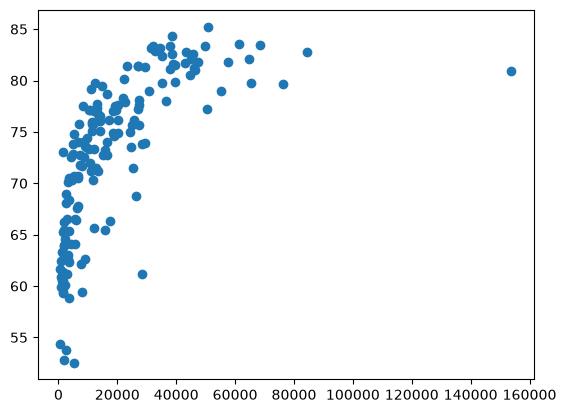

In [11]:
fig,ax=plt.subplots()
ax.scatter(x,y)
plt.show()

You can also put the pandas columns right into scatter

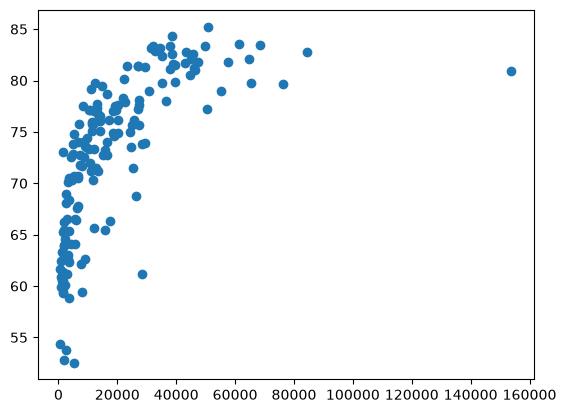

In [12]:
fig,ax=plt.subplots()
ax.scatter(df['GDP per capita'],df['LifeExpectancy'])
plt.show()

To keep things easier and clean for now lets set the x and y and make the plot all in one cell

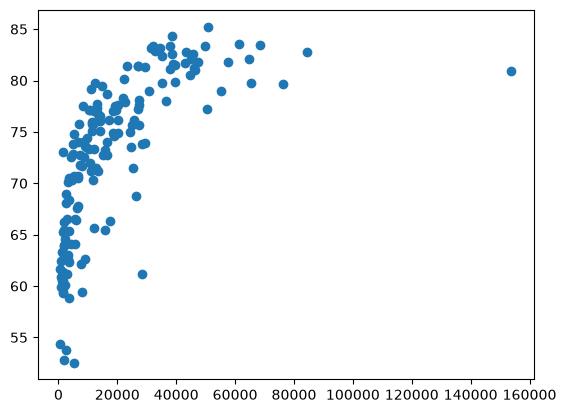

In [13]:
x=df['GDP per capita']
y=df['LifeExpectancy']

fig,ax=plt.subplots()
ax.scatter(x,y)
plt.show()

Then now let's see how a line fits through the data.

In [14]:
stats.linregress(x,y)

LinregressResult(slope=0.0002549989236354205, intercept=67.77266129270281, rvalue=0.6658147349858892, pvalue=1.7223524086251126e-22, stderr=2.2381961326783343e-05, intercept_stderr=0.6228910189586092)

#### Now format it and name it like we did last class.  

In [17]:
LinResult = stats.linregress(x,y)
textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)
print(textstr)

m=0.000
b=67.773
$r^2$=0.443
p=0.000


Can you add the line a nice box with the important data?
* On the ax.set_xlabel and ylabel I added the keyword fontsize to make the labels bigger. 

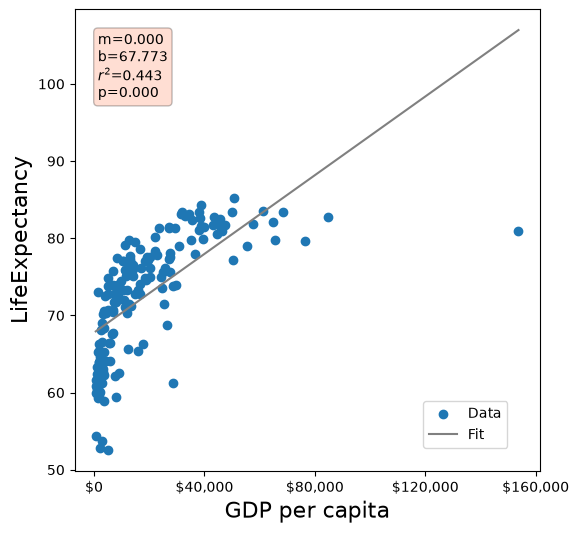

We need to talk x-fit and y-fit.   The point of x-fit is to give a range over which you want to print your line.  You control python and thus control the range of numbers in x_ft.  Some options
1. just use x.  this gives the exact dimensions and I am starting to do this more.
1. Use the min and max of x.  it just gives two numbers so clean that way.  But if you just use x you get the min and max
1. Just give it numbers you like.  The downside is you need to keep resetting them.  remember for this you need to pass np.array([#1, #2])

Go back to your graph and set x_fit to each of these bullets above and see if you get what you expect.  My graph below is setting it to the numbers I wanted.

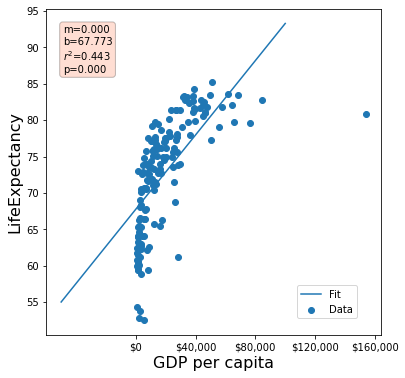

### The fit is bad!!!! 
- p-value says the fit is statistically signicant.  
- But it doesn't capture the overall trend.
- I am not happy with the fit.  The data is curved and our line is straight.
- Let's see what happens if we log the data.  Remember in computer speak log is really ln or natural log and if you want log10 you need log10

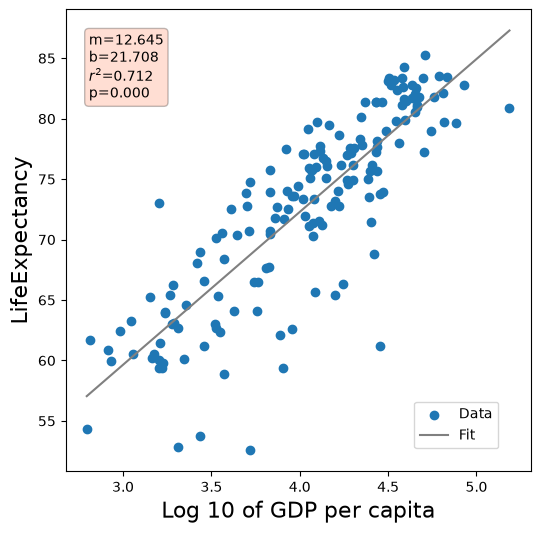

In [28]:
# get the data
x=np.log10(df['GDP per capita'])
y=df['LifeExpectancy']

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('Log 10 of GDP per capita',fontsize=16)
ax.set_ylabel('LifeExpectancy',fontsize=16)

#### Do the best fit line and plot it
LinResult = stats.linregress(x,y)

x_fit=np.linspace(min(x),max(x))
y_fit=x_fit*LinResult.slope+LinResult.intercept
ax.plot(x_fit,y_fit,label='Fit',color='gray')

# Use a comma in the x-axis with dollar signs
#ax.xaxis.set_major_formatter('${x:,}')

#make a larger step size on x-axis
#stepsize=40000
#ax.xaxis.set_ticks(np.arange(0, 160001, stepsize))

### Add the text box with fit data
props=dict(boxstyle='round',facecolor='coral',alpha=0.25)

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)

ax.text(0.05,0.95,textstr,transform=ax.transAxes,fontsize=10\
        ,verticalalignment='top',bbox=props)

#Add the legend
ax.legend(loc=(.75,0.05))

That is a great fit.  Can you try doing 
* Log10 of life Expectancy versus GDP
* Log10 of Life Expectancy versus Log10 of GDP

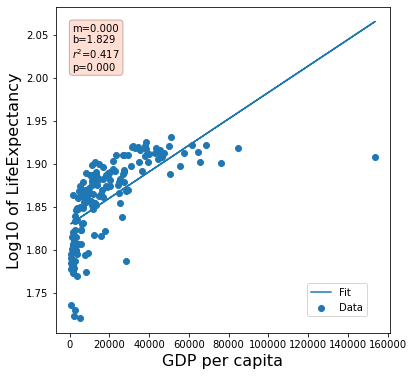

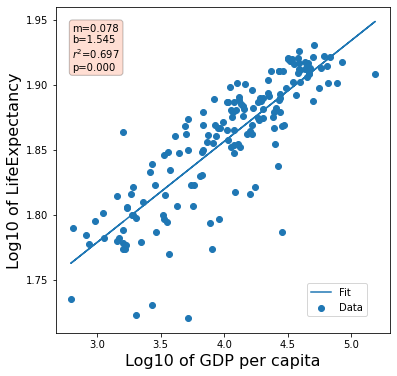

The log10 of GDP per capita does give a nice fit!  

Also if you want log paper you can use 
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.loglog.html

https://matplotlib.org/stable/gallery/scales/log_demo.html



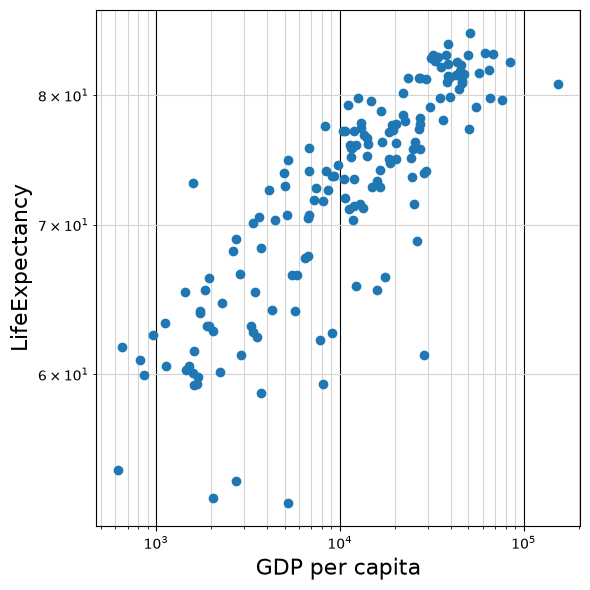

In [19]:
x=df['GDP per capita']
y=df['LifeExpectancy']

fig,ax=plt.subplots(layout='tight')  #layout='tight' makes sure nothing is cutoff
fig.set_size_inches(6,6)

ax.loglog(x,y,linestyle='none',marker='o',base=10)

#This adds the major and minor grids and makes them slightly different colors
ax.grid(True,which="minor",ls="-", color='lightgrey')
ax.grid(True,which="major",ls="-", color='k')

ax.set_xlabel('GDP per capita',fontsize=16)
ax.set_ylabel('LifeExpectancy',fontsize=16)

plt.show()

To review today you should have read data in to a dataframe df with Pandas and then found a best fit line.  We also looked at the log of the data to find a better fit.  Then we plotted on log paper.  Adding a line on log paper is annoying so we did not do that.  


below I show you two more things.  First I show you how I transformed the data from the website.  Then I try to replicate the graph from the website.

## Always Loot at the data!
#### Anscombe's Quartet 
- The point of this exercsie is to make you look at data
- Data can have the same statistics but be very different in the underlying structure
- Read in the file Fits.xlsx
- Each sheet Sheet1, Sheet2, Sheet3, Sheet4, Sheet5 has very different shapes
- Plot each sheet
- Compare the statistics of each sheet.  Are they similar?
- I started the code.  Use your code from above to finish.  

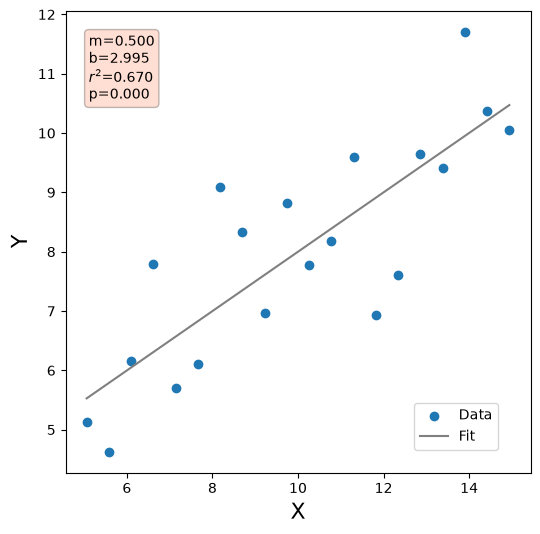

In [30]:
# read the data
df=pd.read_excel('Fits.xlsx',sheet_name='Sheet1')

# get the data
x=df['X']
y=df['Y']

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('X',fontsize=16)
ax.set_ylabel('Y',fontsize=16)

#### Do the best fit line and plot it




### Add the text box with fit data




#Add the legend



### Use Gemini to replicate online graph
- Can we have AI make the same graph as online
- Use Geminin Thinking 3.6
- Here are my directions.

Using the attached file GDP_LifeExpectancy2018.csv can we make a plot of GDP versus life expectancy.  
- Have the size of the scatter points scalue with population
- Color the points by continent
- Label the points with the name of the Country if PringName==TRUE
- Add legends for the continents and the size of the points
- Add dollar signs to the GDP values on the x-axis
- use fig,ax=plt.subplots nomenclature
- only use matplotlib
- I am running Python 3.11.15 with Matplotlib 3.11.1 in JupyterLab 4.6.3 on macOS. Please write code compatible with these versions

See if you get a similar answer or need to give more prompts.  I deleted my code.  I would try and move the continent legend so it doesn't block points.  Also, you can upload a photo and just say copy with this data.  


In [44]:
import sys
import matplotlib
import jupyterlab

print("Python version:    ", sys.version.split()[0])
print("Matplotlib version:", matplotlib.__version__)
print("JupyterLab version:", jupyterlab.__version__)

Python version:     3.11.15
Matplotlib version: 3.11.1
JupyterLab version: 4.6.3


findfont: Failed to find font weight medium, now using 400.


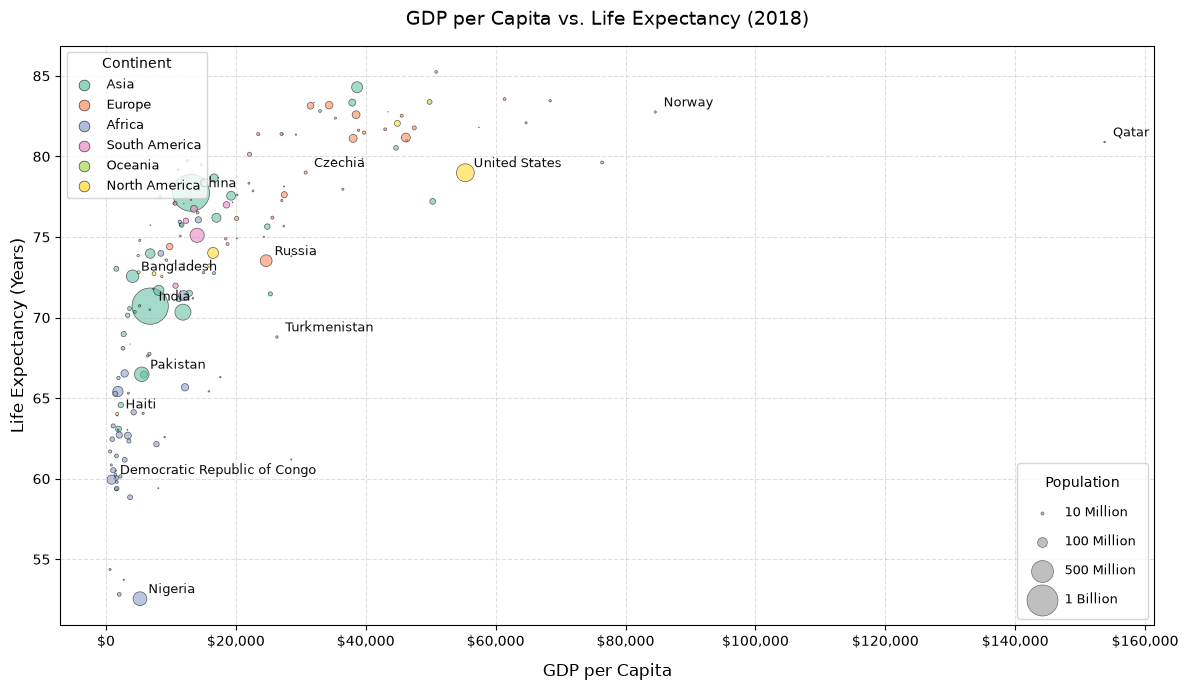

# Answers

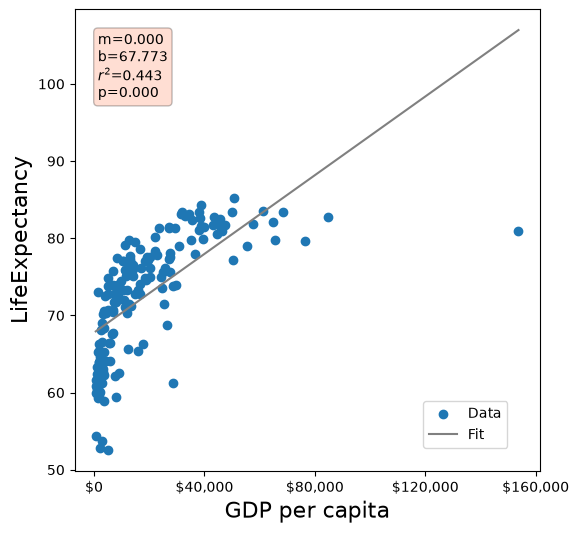

In [19]:
# get the data
x=df['GDP per capita']
y=df['LifeExpectancy']

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('GDP per capita',fontsize=16)
ax.set_ylabel('LifeExpectancy',fontsize=16)

#### Do the best fit line and plot it
LinResult = stats.linregress(x,y)

x_fit=np.linspace(min(x),max(x))
y_fit=x_fit*LinResult.slope+LinResult.intercept
ax.plot(x_fit,y_fit,label='Fit',color='gray')

# Use a comma in the x-axis with dollar signs
ax.xaxis.set_major_formatter('${x:,}')

#make a larger step size on x-axis
stepsize=40000
ax.xaxis.set_ticks(np.arange(0, 160001, stepsize))

### Add the text box with fit data
props=dict(boxstyle='round',facecolor='coral',alpha=0.25)

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)

ax.text(0.05,0.95,textstr,transform=ax.transAxes,fontsize=10\
        ,verticalalignment='top',bbox=props)

#Add the legend
ax.legend(loc=(.75,0.05))

### Choosing my own x-fit

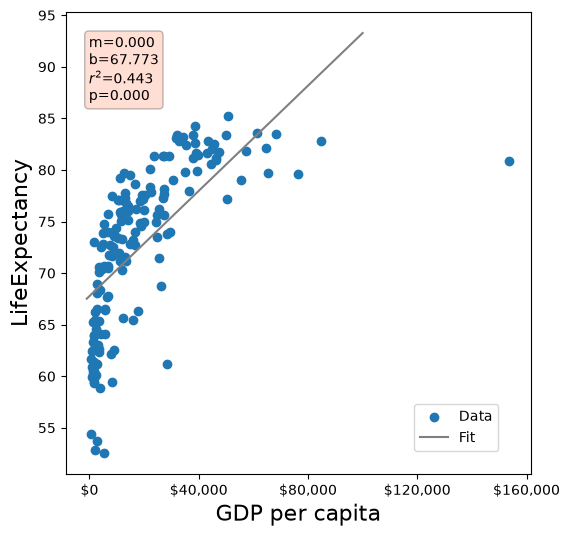

In [38]:
# re-reading data 
df=pd.read_excel('GDP_LifeExpectancy2018.xlsx')

# get the data
x=df['GDP per capita']
y=df['LifeExpectancy']

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('GDP per capita',fontsize=16)
ax.set_ylabel('LifeExpectancy',fontsize=16)

#### Do the best fit line and plot it
LinResult = stats.linregress(x,y)

x_fit=np.array([-1000,100000])
y_fit=x_fit*LinResult.slope+LinResult.intercept
ax.plot(x_fit,y_fit,label='Fit',color='gray')

# Use a comma in the x-axis with dollar signs
ax.xaxis.set_major_formatter('${x:,}')

#make a larger step size on x-axis
stepsize=40000
ax.xaxis.set_ticks(np.arange(0, 160001, stepsize))

### Add the text box with fit data
props=dict(boxstyle='round',facecolor='coral',alpha=0.25)

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)

ax.text(0.05,0.95,textstr,transform=ax.transAxes,fontsize=10\
        ,verticalalignment='top',bbox=props)

#Add the legend
ax.legend(loc=(.75,0.05))

## Adding log10

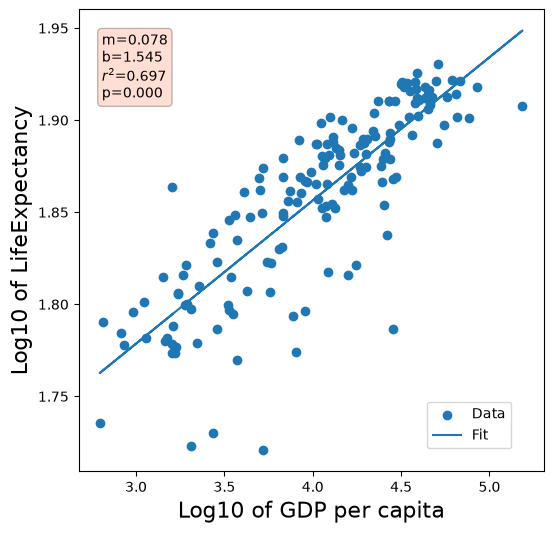

In [40]:
# get the data
x=np.log10(df['GDP per capita'])
y=np.log10(df['LifeExpectancy'])

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('Log10 of GDP per capita',fontsize=16)
ax.set_ylabel('Log10 of LifeExpectancy',fontsize=16)

#### Do the best fit line and plot it
LinResult = stats.linregress(x,y)

x_fit=x
y_fit=x_fit*LinResult.slope+LinResult.intercept
ax.plot(x_fit,y_fit,label='Fit')

# Use a comma in the x-axis for dollars
#ax.xaxis.set_major_formatter('${x:,}')

#make a larger step size on x-axis
#ax.xaxis.set_ticks(np.arange(0, 160001, stepsize))

### Add the text box with fit data
props=dict(boxstyle='round',facecolor='coral',alpha=0.25)

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)

ax.text(0.05,0.95,textstr,transform=ax.transAxes,fontsize=10\
        ,verticalalignment='top',bbox=props)

#Add the legend
ax.legend(loc=(.75,0.05))

## Anscombe's Quartet

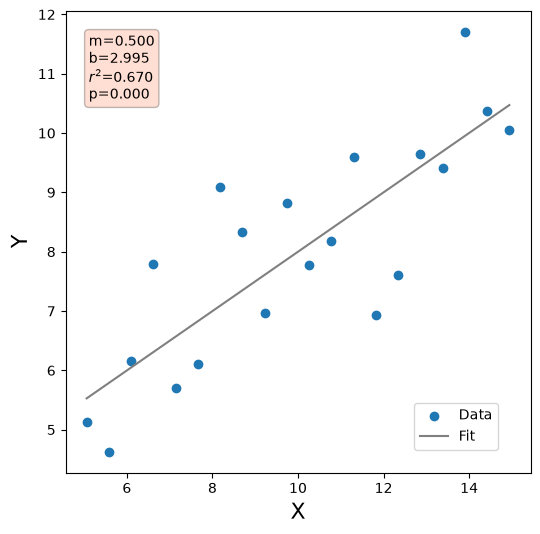

In [36]:
# read the data
df=pd.read_excel('Fits.xlsx',sheet_name='Sheet1')

# get the data
x=df['X']
y=df['Y']

# plot the data
fig,ax=plt.subplots()
fig.set_size_inches(6,6)
ax.scatter(x,y,label='Data')

ax.set_xlabel('X',fontsize=16)
ax.set_ylabel('Y',fontsize=16)

#### Do the best fit line and plot it
LinResult = stats.linregress(x,y)

x_fit=np.linspace(min(x),max(x))
y_fit=x_fit*LinResult.slope+LinResult.intercept
ax.plot(x_fit,y_fit,label='Fit',color='gray')

### Add the text box with fit data
props=dict(boxstyle='round',facecolor='coral',alpha=0.25)

textstr='m={:.3f}\nb={:.3f}\n$r^2$={:.3f}\np={:.3f}'\
            .format(LinResult.slope,LinResult.intercept
                    ,LinResult.rvalue**2,LinResult.pvalue)

ax.text(0.05,0.95,textstr,transform=ax.transAxes,fontsize=10\
        ,verticalalignment='top',bbox=props)

#Add the legend
ax.legend(loc=(.75,0.05))

### Use Gemini to replicate online graph
- Can we have AI make the same graph as online
- Use Geminin Thinking 3.6
- Here are my directions.

Using the attached file GDP_LifeExpectancy2018.csv can we make a plot of GDP versus life expectancy.  
- Have the size of the scatter points scalue with population
- Color the points by continet
- Label the points with the name of the Country if PringName==TRUE
- Add legends for the continents and the size of the points
- Add dollar signs to the GDP values on the x-axis
- use fig,ax=plt.subplots nomenclature
- only use matplotlib
- I am running Python 3.11.15 with Matplotlib 3.11.1 in JupyterLab 4.6.3 on macOS. Please write code compatible with these versions

See if you get a similar answer or need to give more prompts.  I deleted my code.  


In [44]:
import sys
import matplotlib
import jupyterlab

print("Python version:    ", sys.version.split()[0])
print("Matplotlib version:", matplotlib.__version__)
print("JupyterLab version:", jupyterlab.__version__)

Python version:     3.11.15
Matplotlib version: 3.11.1
JupyterLab version: 4.6.3


findfont: Failed to find font weight medium, now using 400.


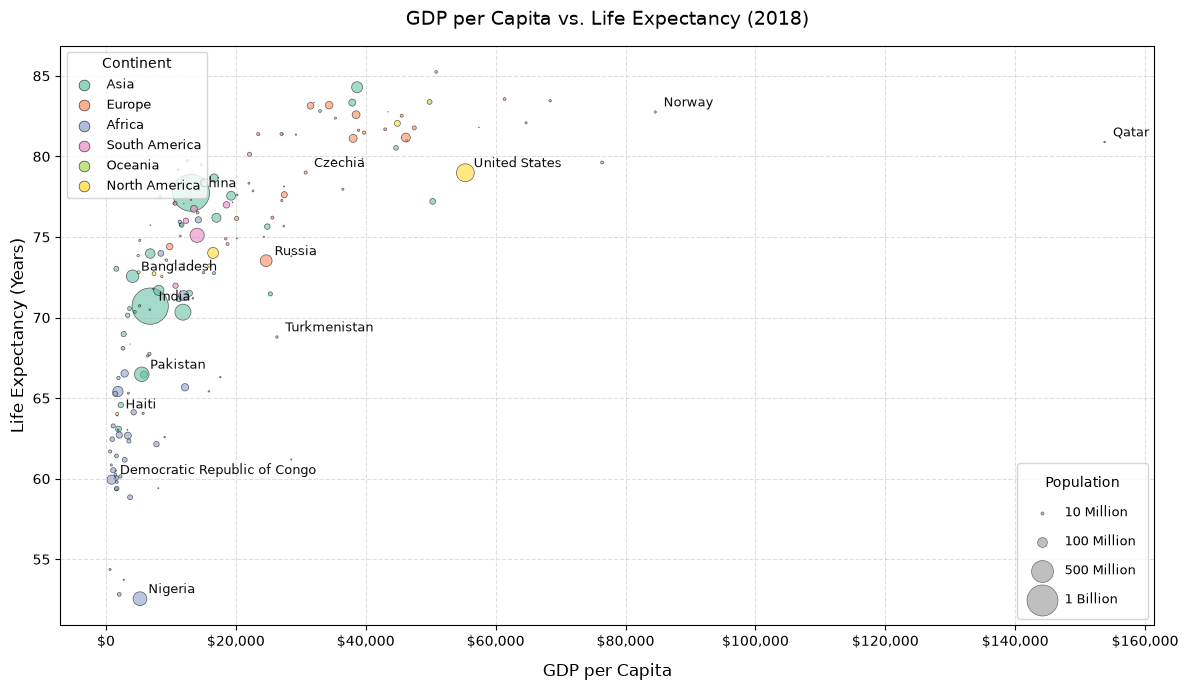

## Extra Part 1

### How I cleaned the data

If you want to know how I took the data from the website to our class all the data is below. I downloaded the raw data 
https://ourworldindata.org/grapher/life-expectancy-vs-gdp-per-capita?xScale=linear

Firest I read it n and printed the column names

In [21]:
df=pd.read_csv('life-expectancy-vs-gdp-per-capita.csv')

In [22]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Period life expectancy at birth - Sex: all - Age: 0', 'GDP per capita',
       '417485-annotations', 'Population (historical estimates)', 'Continent'],
      dtype='object')

Renamed columns to sometime easier

In [23]:
df.rename(columns={'Entity': 'Country'
                    ,'Period life expectancy at birth - Sex: all - Age: 0': 'LifeExpectancy'
                   ,'Population (historical estimates)':'Population'
                   }
                   ,inplace=True)

In [24]:
df.columns

Index(['Country', 'Code', 'Year', 'LifeExpectancy', 'GDP per capita',
       '417485-annotations', 'Population', 'Continent'],
      dtype='object')

I took years 2018 and 2015.  2015 has the continent and 2018 is the last year with all the data

In [25]:
df=df[(df.Year==2018)|(df.Year==2015)]

I group the two lines into one

In [26]:
agg_f={'Code':'last'
       , 'Year':'last'
       ,'LifeExpectancy':'last'
       , 'GDP per capita':'last'
       ,'417485-annotations':'last'
       ,'Population':'last'
       , 'Continent':'first'
}
dfG=df.groupby(['Country']).agg(agg_f)


I drop missing data

In [27]:
dfG.dropna(subset=['LifeExpectancy'
                   ,'GDP per capita'
                  ,'Continent'],inplace=True)

Get rid of the weird column and save to excel

In [28]:
dfG.drop('417485-annotations',axis=1,inplace=True)

In [29]:
dfG.to_excel('GDP_LifeExpectancy2018_original.xlsx')

## Extra Part 2

#### Make Dataset with Gemini help looking at fits for Anscombe's Quartet
- Sheet1 - Linear
- Sheet2 - Quadratic
- Sheet3 - Outlier
- Sheet4 - High Leverage
- Sheet5 - Heteroscedastic
- "anscombe_5_tabs_20_points.xlsx"

In [30]:
import pandas as pd

datasets = {
    "Sheet1": {
        "X": [5.06, 5.58, 6.10, 6.62, 7.14, 7.66, 8.18, 8.70, 9.22, 9.74, 10.26, 10.78, 11.30, 11.82, 12.34, 12.86, 13.38, 13.90, 14.42, 14.94],
        "Y": [5.13, 4.63, 6.15, 7.80, 5.70, 6.10, 9.09, 8.33, 6.97, 8.82, 7.78, 8.18, 9.59, 6.93, 7.60, 9.65, 9.41, 11.71, 10.37, 10.05]
    },
    "Sheet2": {
        "X": [5.06, 5.58, 6.10, 6.62, 7.14, 7.66, 8.18, 8.70, 9.22, 9.74, 10.26, 10.78, 11.30, 11.82, 12.34, 12.86, 13.38, 13.90, 14.42, 14.94],
        "Y": [3.50, 4.40, 5.23, 5.99, 6.68, 7.29, 7.84, 8.31, 8.71, 9.04, 9.30, 9.49, 9.61, 9.66, 9.63, 9.54, 9.37, 9.13, 8.83, 8.45]
    },
    "Sheet3": {
        "X": [5.06, 5.58, 6.10, 6.62, 7.14, 7.66, 8.18, 8.70, 9.22, 9.74, 10.26, 10.78, 11.30, 11.82, 12.34, 12.86, 13.38, 13.90, 14.42, 14.94],
        "Y": [5.98, 6.16, 6.35, 6.53, 6.72, 6.90, 7.09, 7.28, 7.46, 7.65, 7.83, 8.02, 8.20, 8.39, 8.57, 8.76, 8.95, 9.13, 9.32, 14.72]
    },
    "Sheet4": {
        "X": [9.31]*19 + [23.08],
        "Y": [5.88, 6.08, 6.28, 6.47, 6.67, 6.87, 7.06, 7.26, 7.46, 7.66, 7.85, 8.05, 8.25, 8.44, 8.64, 8.84, 9.04, 9.23, 9.43, 14.54]
    },
    "Sheet5": {
        "X": [5.06, 5.58, 6.10, 6.62, 7.14, 7.66, 8.18, 8.70, 9.22, 9.74, 10.26, 10.78, 11.30, 11.82, 12.34, 12.86, 13.38, 13.90, 14.42, 14.94],
        "Y": [5.55, 6.02, 5.94, 6.58, 6.33, 7.19, 6.71, 7.81, 7.10, 8.42, 7.38, 9.09, 7.66, 9.81, 7.82, 10.65, 7.99, 11.49, 7.93, 12.55]
    }
}

with pd.ExcelWriter("Fits.xlsx") as writer:
    for sheet_name, cols in datasets.items():
        pd.DataFrame(cols).to_excel(writer, sheet_name=sheet_name, index=False)

### new page
<div style="page-break-before: always;"></div>


# Exit Ticket
## Name:
## uni:

### Q1. Sketch two graphs with some scatter points and a best fit line.  Make the graphs have similar r$^2$ but different distribution of points.  


<div style="page-break-before: always;"></div>
### Ignore.  For printing to pdf.  

In [3]:
%%html
<style>
@media print {
    body {
        zoom: 0.80; /* Scales everything down to 80% of original size */
    }
}
</style>

In [4]:
import ipynbname
from pypdf import PdfReader, PdfWriter

# Dynamically fetch the current notebook's name (without the .ipynb extension)
filename = ipynbname.name()

# Convert to PDF
!uv run jupyter nbconvert --to webpdf {filename}.ipynb

# Strip the last page
reader = PdfReader(f"{filename}.pdf")
writer = PdfWriter()
for page in reader.pages[:-1]:
    writer.add_page(page)
writer.write(f"{filename}.pdf")

[NbConvertApp] Converting notebook more-line-fit.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 694747 bytes to more-line-fit.pdf


(True, <_io.FileIO [closed]>)